In [3]:
import os
import librosa
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

BASE_PATH = "/kaggle/input/datasets/alieldinalaa/nn-cmp27-dataset" 
TARGET_SR = 48000
DATA_FRACTION = 0.20 # Act on only 20% of the data

K_MAP = {
    "Machine 1_Normal": 18, "Machine 1_Abnormal": 3,
    "Machine 2_Normal": 9, "Machine 2_Abnormal": 3,
    "Machine 3_Normal": 4, "Machine 3_Abnormal": 2
}

LABEL_MAP = {
    "Machine 1_Normal": 0, "Machine 1_Abnormal": 1,
    "Machine 2_Normal": 2, "Machine 2_Abnormal": 3,
    "Machine 3_Normal": 4, "Machine 3_Abnormal": 5
}

def fast_1d_extract(file_path):
    """Extremely fast extraction just to find the background noise signatures for clustering."""
    try:
        y, sr = librosa.load(file_path, sr=TARGET_SR, duration=10.0)
        mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20), axis=1)
        return mfccs
    except:
        return None

In [ ]:
print("🚀 STEP 1: Scanning files and extracting 1D signatures for clustering...")
all_files = []
for machine in ["Machine 1", "Machine 2", "Machine 3"]:
    for state in ["Normal", "Abnormal"]:
        folder = os.path.join(BASE_PATH, machine, 'machine_data', state)
        if os.path.exists(folder):
            files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith('.wav')]
            for f in files:
                all_files.append({"path": f, "class": f"{machine}_{state}"})

df = pd.DataFrame(all_files)

# Extract 1D features in parallel
features_1d = []
with ProcessPoolExecutor(max_workers=None) as executor:
    futures = {executor.submit(fast_1d_extract, row['path']): idx for idx, row in df.iterrows()}
    for future in tqdm(as_completed(futures), total=len(df), desc="1D Extraction"):
        features_1d.append((futures[future], future.result()))

# Sort back to original dataframe order and assign
features_1d.sort(key=lambda x: x[0])
df['1d_feats'] = [x[1] for x in features_1d]
df = df.dropna(subset=['1d_feats']).reset_index(drop=True)

In [4]:
print("\n🧠 STEP 2: Applying K-Means to identify physical recording sessions...")
df['cluster_id'] = ""
for class_name, k_val in K_MAP.items():
    class_mask = df['class'] == class_name
    X_class = np.vstack(df.loc[class_mask, '1d_feats'].values)
    
    kmeans = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    local_clusters = kmeans.fit_predict(X_class)
    
    # Make cluster IDs globally unique (e.g., "Machine 3_Abnormal_Cluster_0")
    df.loc[class_mask, 'cluster_id'] = [f"{class_name}_C{c}" for c in local_clusters]


🧠 STEP 2: Applying K-Means to identify physical recording sessions...


In [5]:
print("\n🛡️ STEP 3: Guaranteed Split & 20% Reduction...")
train_list, test_list = [], []

for class_name in df['class'].unique():
    class_df = df[df['class'] == class_name]
    unique_clusters = class_df['cluster_id'].unique()
    
    # The Guarantee Logic
    if len(unique_clusters) == 2:
        train_clust, test_clust = [unique_clusters[0]], [unique_clusters[1]]
    elif len(unique_clusters) == 3:
        train_clust, test_clust = [unique_clusters[0], unique_clusters[1]], [unique_clusters[2]]
    else:
        train_clust, test_clust = train_test_split(unique_clusters, test_size=0.2, random_state=42)
        
    train_list.append(class_df[class_df['cluster_id'].isin(train_clust)])
    test_list.append(class_df[class_df['cluster_id'].isin(test_clust)])

train_df = pd.concat(train_list)
test_df = pd.concat(test_list)

# Discard 80% of the data for speed, while maintaining stratifications
train_df = train_df.groupby('class').sample(frac=DATA_FRACTION, random_state=42)
test_df = test_df.groupby('class').sample(frac=DATA_FRACTION, random_state=42)

print(f"✅ Data prepared! Train files: {len(train_df)} | Test files: {len(test_df)}")


🛡️ STEP 3: Guaranteed Split & 20% Reduction...
✅ Data prepared! Train files: 8633 | Test files: 2614


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

def extract_2d_mel(file_path):
    """Converts audio strictly to a 10-second 2D Mel-Spectrogram image."""
    try:
        # duration=10.0 forces truncation. No padding needed!
        y, sr = librosa.load(file_path, sr=TARGET_SR, duration=10.0)
        
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # CNNs need a "channel" dimension (like Grayscale images have 1 channel)
        return mel_spec_db[..., np.newaxis] 
    except:
        return None

In [7]:
print("🖼️ STEP 4: Converting Audio to 2D Mel-Spectrograms (Train)...")
X_train, y_train = [], []
for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Train 2D"):
    mel = extract_2d_mel(row['path'])
    if mel is not None:
        X_train.append(mel)
        y_train.append(LABEL_MAP[row['class']])

🖼️ STEP 4: Converting Audio to 2D Mel-Spectrograms (Train)...


Train 2D:   0%|          | 0/8633 [00:00<?, ?it/s]

In [8]:
print("🖼️ STEP 5: Converting Audio to 2D Mel-Spectrograms (Test)...")
X_test, y_test = [], []
for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Test 2D"):
    mel = extract_2d_mel(row['path'])
    if mel is not None:
        X_test.append(mel)
        y_test.append(LABEL_MAP[row['class']])

X_train, y_train = np.array(X_train), np.array(y_train)
X_test, y_test = np.array(X_test), np.array(y_test)
input_shape = X_train[0].shape

print(f"\n✅ 2D Data Ready! Image Shape: {input_shape}")

🖼️ STEP 5: Converting Audio to 2D Mel-Spectrograms (Test)...


Test 2D:   0%|          | 0/2614 [00:00<?, ?it/s]


✅ 2D Data Ready! Image Shape: (128, 938, 1)


In [9]:
print("\n🏗️ STEP 6: Building the CNN from scratch...")
model = models.Sequential([
    layers.Input(shape=input_shape),
    
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten & Classify
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Prevents overfitting on the small K=2 classes
    layers.Dense(6, activation='softmax') # 6 Classes
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


🏗️ STEP 6: Building the CNN from scratch...


In [10]:
print("\n⚔️ STEP 7: Training the CNN...")
history = model.fit(
    X_train, y_train,
    epochs=10, 
    batch_size=32,
    validation_data=(X_test, y_test)
)


⚔️ STEP 7: Training the CNN...
Epoch 1/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1304s 5s/step - accuracy: 0.5555 - loss: 23.8253 - val_accuracy: 0.8925 - val_loss: 0.3665
Epoch 2/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1201s 4s/step - accuracy: 0.8253 - loss: 0.4779 - val_accuracy: 0.9112 - val_loss: 0.3533
Epoch 3/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1271s 5s/step - accuracy: 0.8468 - loss: 0.4314 - val_accuracy: 0.8432 - val_loss: 0.7969
Epoch 4/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1255s 5s/step - accuracy: 0.8399 - loss: 0.4433 - val_accuracy: 0.8810 - val_loss: 0.7054
Epoch 5/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1217s 5s/step - accuracy: 0.8672 - loss: 0.3771 - val_accuracy: 0.9277 - val_loss: 0.3063
Epoch 6/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1216s 5s/step - accuracy: 0.8693 - loss: 0.3567 - val_accuracy: 0.9040 - val_loss: 0.3228
Epoch 7/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1224s 5s/step - accuracy: 0.8907 - loss: 0.2886 - val_accuracy: 0.8604 - val_loss: 0.4853
Epoch 8/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 1263s 5s/step - a

🔍 LEAKAGE VERIFICATION REPORT
Total Train Clusters: 29
Total Test Clusters: 10
Overlapping Clusters (Must be 0): 0
✅ SUCCESS: Zero session leakage detected. The CNN cannot cheat.

📊 CNN CLASSIFICATION RESULTS
82/82 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step

                    precision    recall  f1-score   support

  Machine 1_Normal     0.9798    0.9277    0.9530       940
Machine 1_Abnormal     0.0000    0.0000    0.0000        19
  Machine 2_Normal     0.9055    0.9898    0.9458       687
Machine 2_Abnormal     1.0000    0.0102    0.0202        98
  Machine 3_Normal     0.9299    0.9958    0.9617       719
Machine 3_Abnormal     0.7313    0.6490    0.6877       151

          accuracy                         0.9055      2614
         macro avg     0.7577    0.5954    0.5947      2614
      weighted avg     0.9258    0.9055    0.8963      2614



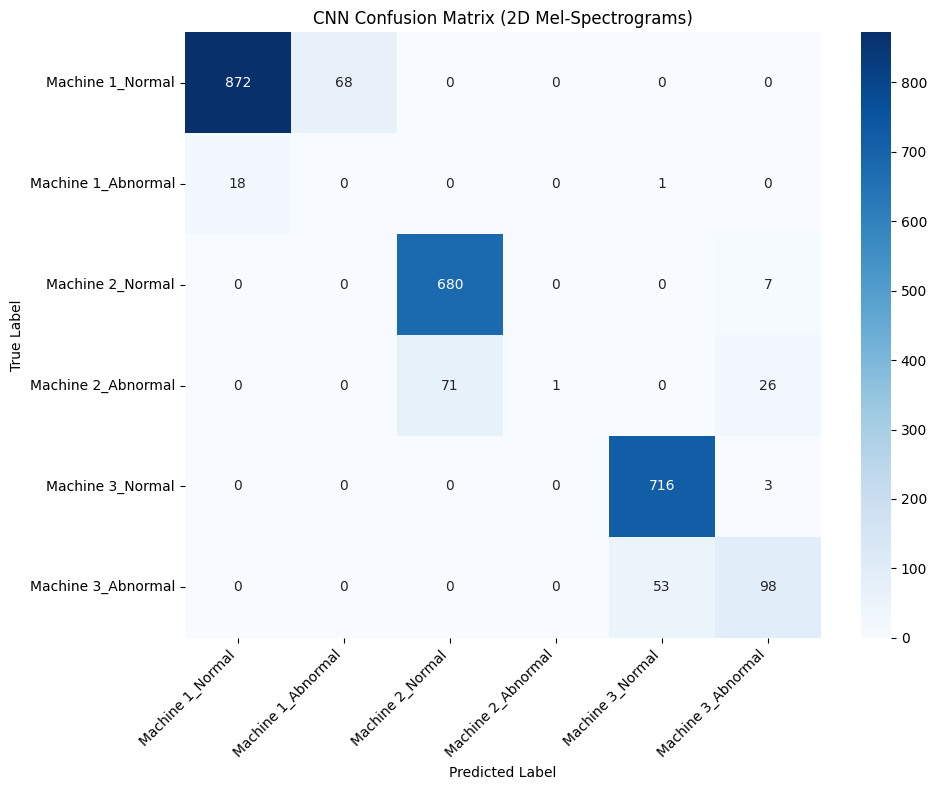

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

print("="*60)
print("🔍 LEAKAGE VERIFICATION REPORT")
print("="*60)

train_clusters = set(train_df['cluster_id'].unique())
test_clusters = set(test_df['cluster_id'].unique())
overlap = train_clusters.intersection(test_clusters)

print(f"Total Train Clusters: {len(train_clusters)}")
print(f"Total Test Clusters: {len(test_clusters)}")
print(f"Overlapping Clusters (Must be 0): {len(overlap)}")

if len(overlap) == 0:
    print("✅ SUCCESS: Zero session leakage detected. The CNN cannot cheat.")
else:
    print(f"❌ WARNING: Leakage detected in clusters: {overlap}")

print("\n" + "="*60)
print("📊 CNN CLASSIFICATION RESULTS")
print("="*60)

# Get predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Reverse the LABEL_MAP to get names for the report
CLASS_NAMES = {v: k for k, v in LABEL_MAP.items()}
target_names = [CLASS_NAMES[i] for i in range(6)]

print("\n" + classification_report(y_test, y_pred, target_names=target_names, digits=4))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('CNN Confusion Matrix (2D Mel-Spectrograms)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()